In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, GaussianNoise
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import Xception, preprocess_input as xcep_preprocess
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


DATA_ROOT = "/content/drive/MyDrive/BoneFractureData"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR = os.path.join(DATA_ROOT, "val")

train_fractured_dir = os.path.join(TRAIN_DIR, 'fractured')
train_not_fractured_dir = os.path.join(TRAIN_DIR, 'not fractured')
val_fractured_dir = os.path.join(VAL_DIR, 'fractured')
val_not_fractured_dir = os.path.join(VAL_DIR, 'not fractured')

MODEL_NAME = "bone_xception_model"
OUT_DIR = os.path.join("/content", MODEL_NAME)
os.makedirs(OUT_DIR, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4
DROP_RATE = 0.4
NUM_CLASSES = 2

labels = ['Train Fractured', 'Train Not Fractured', 'Validation Fractured', 'Validation Not Fractured']

In [4]:
fractured_images = os.listdir(train_fractured_dir)
not_fractured_images = os.listdir(train_not_fractured_dir)

df_fractured = pd.DataFrame({
    'filename': fractured_images,
    'label': 'fractured'
})
df_not_fractured = pd.DataFrame({
    'filename': not_fractured_images,
    'label': 'not fractured'
})

df = pd.concat([df_fractured, df_not_fractured], ignore_index=True)

df['file_path'] = df.apply(lambda row: os.path.join(train_fractured_dir if row['label'] == 'fractured' else train_not_fractured_dir, row['filename']), axis=1)

In [5]:
df = df[['file_path', 'label']]

In [6]:
from imblearn.over_sampling import RandomOverSampler

In [7]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['file_path']], df['label'])

In [8]:
df_resampled = pd.DataFrame(X_resampled, columns=['file_path'])
df_resampled['label'] = y_resampled

In [9]:
print("\nClass distribution after oversampling:")
print(df_resampled['label'].value_counts())


Class distribution after oversampling:
label
fractured        4480
not fractured    4480
Name: count, dtype: int64


In [10]:
df_resampled.to_csv('bone_fracture.csv')

In [11]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['label']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['label']
)

In [12]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='file_path',
    y_col='label',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='file_path',
    y_col='label',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)
test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='file_path',
    y_col='label',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 7168 validated image filenames belonging to 2 classes.
Found 896 validated image filenames belonging to 2 classes.
Found 896 validated image filenames belonging to 2 classes.


In [ ]:
def create_xception_model_functional(input_shape=(224, 224, 3), pretrained_weights="imagenet",
                                    dropout_rate=0.25, dense_units=512, freeze_base=True):

    inputs = Input(shape=input_shape, name="input_image")

    base_model = Xception(
        include_top=False,
        weights=pretrained_weights,
        input_tensor=inputs,
        pooling=None,
    )

    if freeze_base:
        for layer in base_model.layers:
            layer.trainable = False

    x = base_model.output
    x = GaussianNoise(0.25, name="gn_1")(x)
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = Dense(dense_units, activation="relu", name="dense_1")(x)
    x = BatchNormalization(name="bn_1")(x)
    x = GaussianNoise(0.25, name="gn_2")(x)
    x = Dropout(dropout_rate, name="dropout_1")(x)
    outputs = Dense(1, activation="sigmoid", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="xception_binary_functional")
    return model, base_model


input_shape = (224, 224, 3)
model, base_model = create_xception_model_functional(input_shape=input_shape,
                                                     pretrained_weights="imagenet",
                                                     dropout_rate=0.25,
                                                     dense_units=512,
                                                     freeze_base=True)

model.compile(
    optimizer=optimizers.Adam(LR),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

Model: "xception_binary_functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_image[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_36[0][0]    

 Total params: 21,913,129 (83.59 MB)

 Trainable params: 1,050,625 (4.01 MB)

 Non-trainable params: 20,862,504 (79.58 MB)

In [39]:
history = model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 1832s 4s/step - accuracy: 0.6617 - auc: 0.7229 - loss: 0.6628 - val_accuracy: 0.8203 - val_auc: 0.9195 - val_loss: 0.3938
Epoch 2/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 131s 292ms/step - accuracy: 0.7720 - auc: 0.8573 - loss: 0.4773 - val_accuracy: 0.8739 - val_auc: 0.9417 - val_loss: 0.3127
Epoch 3/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 129s 288ms/step - accuracy: 0.8073 - auc: 0.8926 - loss: 0.4133 - val_accuracy: 0.8772 - val_auc: 0.9524 - val_loss: 0.2973
Epoch 4/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 132s 294ms/step - accuracy: 0.8037 - auc: 0.8901 - loss: 0.4178 - val_accuracy: 0.8929 - val_auc: 0.9563 - val_loss: 0.2801
Epoch 5/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 131s 293ms/step - accuracy: 0.8348 - auc: 0.9158 - loss: 0.3679 - val_accuracy: 0.8962 - val_auc: 0.9612 - val_loss: 0.2604
Epoch 6/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 133s 297ms/step - accuracy: 0.8336 - auc: 0.9152 - loss: 0.3694 - val_accuracy: 0.8783 - val_auc: 0.9614 - val_loss: 0.2812
Epoch 7/10
448/448

In [ ]:
keras_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.keras")
h5_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.h5")
saved_dir = os.path.join(OUT_DIR, "exported_for_serving")

try:
    model.save(keras_file, include_optimizer=False)
    print("Saved Keras single-file:", keras_file)
except Exception as e:
    print("Saving .keras failed:", e)

try:
    model.save(h5_file, include_optimizer=False)
    print("Saved HDF5:", h5_file)
except Exception as e:
    print("HDF5 save failed (ok if .keras exists):", e)

try:
    if hasattr(model, "export"):
        model.export(saved_dir)
        print("Saved model.export to:", saved_dir)
    else:
        tf.saved_model.save(model, saved_dir)
        print("Saved tf.saved_model to:", saved_dir)
except Exception as e:
    print("SavedModel export failed:", e)

meta = {
    "input_size": [IMAGE_SIZE[0], IMAGE_SIZE[1]],
    "preprocessing": "xception_preprocess",
    "class_labels": ["fractured", "not fractured"],
    "last_conv_layer": "block14_sepconv2"
}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f)

shutil.make_archive(OUT_DIR + "_bundle", 'zip', OUT_DIR)
print("Model bundle saved to:", OUT_DIR)


In [13]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('/content/bone_xception_model.keras')

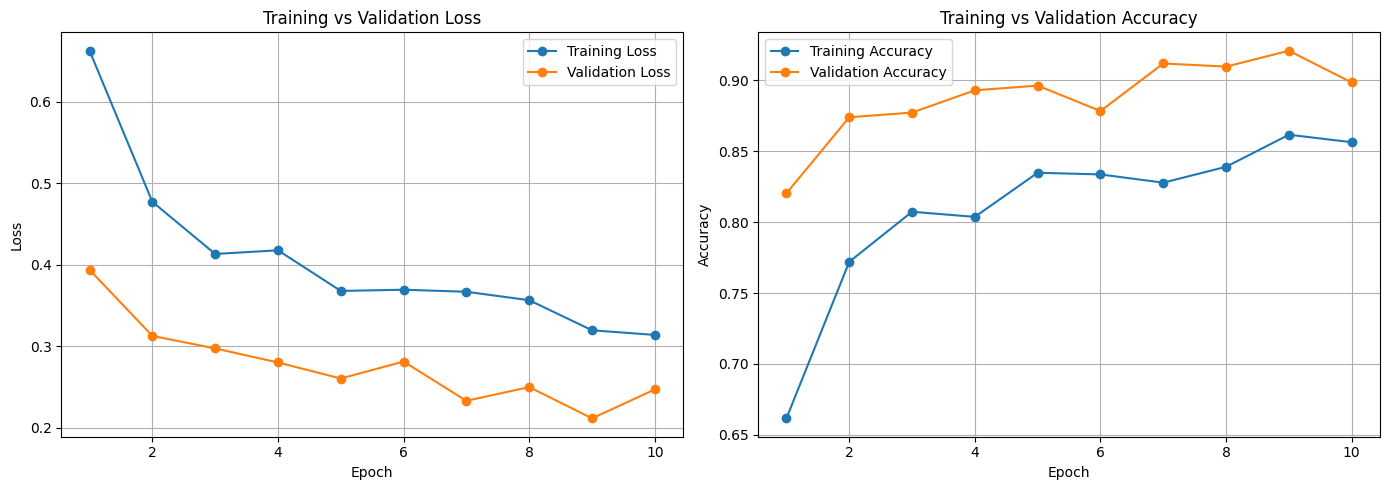

In [19]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
loss = [
    0.6628, 0.4773, 0.4133, 0.4178, 0.3679,
    0.3694, 0.3669, 0.3565, 0.3196, 0.3139
]

val_loss = [
    0.3938, 0.3127, 0.2973, 0.2801, 0.2604,
    0.2812, 0.2330, 0.2499, 0.2115, 0.2470
]

accuracy = [
    0.6617, 0.7720, 0.8073, 0.8037, 0.8348,
    0.8336, 0.8278, 0.8390, 0.8616, 0.8563
]

val_accuracy = [
    0.8203, 0.8739, 0.8772, 0.8929, 0.8962,
    0.8783, 0.9118, 0.9096, 0.9208, 0.8984
]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, marker='o', label="Training Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, marker='o', label="Training Accuracy")
plt.plot(epochs, val_accuracy, marker='o', label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


56/56 ━━━━━━━━━━━━━━━━━━━━ 1504s 27s/step


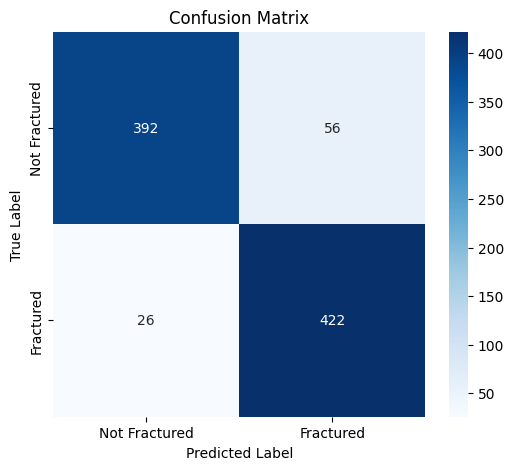

In [20]:
# Confusion Matrix Plot
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
test_labels = test_gen_new.classes
predictions = model.predict(test_gen_new)
predicted_labels = (predictions > 0.5).astype(int).flatten()

conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fractured', 'Fractured'],
            yticklabels=['Not Fractured', 'Fractured'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()